# Q3: Phân Tích Hoạt Động Đại Lý — RFM + Churn Prediction
## Xác Suất Đặt Hàng Lại & Phân Đoạn Rủi Ro

**Câu hỏi kinh doanh:**
1. Đại lý nào có nguy cơ churn cao?
2. Xác suất đại lý đặt hàng trong Q2/2026 là bao nhiêu?

**Template:** r15 (Customer-Segmentation-RFM-CLV — cấu trúc RFM quintile) + r14 (BG-NBD/CLV từ lifetimes)

**Phương pháp:**
- Model 1: RFM rule-based scoring
- Model 2: Logistic Regression (sklearn) → predict reorder_30d
- Model 3: BG-NBD via lifetimes (nếu cài được)

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, accuracy_score,
                              precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')
print('Core imports OK')

Core imports OK


In [2]:
# Cell 2: Load dữ liệu bán hàng
df = pd.read_csv('../data/fact_sales.csv', low_memory=False)
df['order_date'] = pd.to_datetime(df['order_date'])
df['product_code'] = df['product_code'].astype(str).str.strip().str.zfill(15)
df['seg2_group'] = df['product_code'].str[6:9]
df['year_month'] = df['order_date'].dt.to_period('M')

# Lọc dữ liệu sạch
df = df[(df['year_month'].astype(str) != '2026-03') & (df['seg2_group'] != '00U')]
print(f'Dữ liệu sạch: {len(df):,} dòng')
print(f'Số đại lý: {df["customer_code"].nunique()}')

Dữ liệu sạch: 34,062 dòng
Số đại lý: 702


In [3]:
# Cell 3: Tính RFM (từ r15 exact code pattern)
REFERENCE_DATE = pd.Timestamp('2026-03-01')

rfm = df.groupby('customer_code').agg(
    recency=('order_date', lambda x: (REFERENCE_DATE - x.max()).days),
    frequency=('so_number', 'nunique'),
    monetary=('line_total', 'sum')
).reset_index()

# Gắn tên đại lý
dealer_names = df.groupby('customer_code')['customer_name'].first().reset_index()
rfm = rfm.merge(dealer_names, on='customer_code', how='left')

print(f'RFM computed cho {len(rfm)} đại lý')
print(rfm[['recency','frequency','monetary']].describe().round(0))

RFM computed cho 702 đại lý
       recency  frequency      monetary
count    702.0      702.0  7.020000e+02
mean     157.0        2.0  1.955587e+08
std      165.0        4.0  5.335454e+08
min        1.0        1.0  2.944444e+06
25%       17.0        1.0  4.819388e+07
50%       34.0        1.0  9.009221e+07
75%      341.0        2.0  1.770800e+08
max      419.0       67.0  9.957719e+09


In [4]:
# Cell 4: RFM quintile scoring (r15 exact pattern — replace var names)
def rfm_quintile_score(x, col, ascending=True):
    """Score 1-5 based on quintiles."""
    try:
        q = pd.qcut(x[col], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop')
    except Exception:
        q = pd.cut(x[col], bins=5, labels=[1, 2, 3, 4, 5])
    if not ascending:
        q = 6 - q.astype(int)  # invert: lower recency = better
        return q
    return q.astype(int)

rfm['R_score'] = rfm_quintile_score(rfm, 'recency', ascending=False)
rfm['F_score'] = rfm_quintile_score(rfm, 'frequency', ascending=True)
rfm['M_score'] = rfm_quintile_score(rfm, 'monetary', ascending=True)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print('RFM Score distribution:')
print(rfm[['R_score','F_score','M_score','RFM_total']].describe().round(1))

RFM Score distribution:
       R_score  F_score  M_score  RFM_total
count    702.0    702.0    702.0      702.0
mean       3.1      1.0      3.0        7.1
std        1.4      0.3      1.4        2.4
min        1.0      1.0      1.0        3.0
25%        2.0      1.0      2.0        5.0
50%        3.0      1.0      3.0        7.0
75%        4.0      1.0      4.0        9.0
max        5.0      5.0      5.0       15.0


In [5]:
# Cell 5: Segment assignment (từ r15 — Champions/Loyal/At-Risk/Lost/New)
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    total = r + f + m
    if total >= 12:
        return 'Champions'
    elif total >= 9 and r >= 4:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r == 1:
        return 'Lost'
    else:
        return 'Potential'

rfm['segment'] = rfm.apply(assign_segment, axis=1)
seg_counts = rfm['segment'].value_counts()
print('Phân đoạn đại lý:')
print(seg_counts)

Phân đoạn đại lý:
segment
Potential    282
Loyal        181
Lost         135
New          100
Champions      4
Name: count, dtype: int64


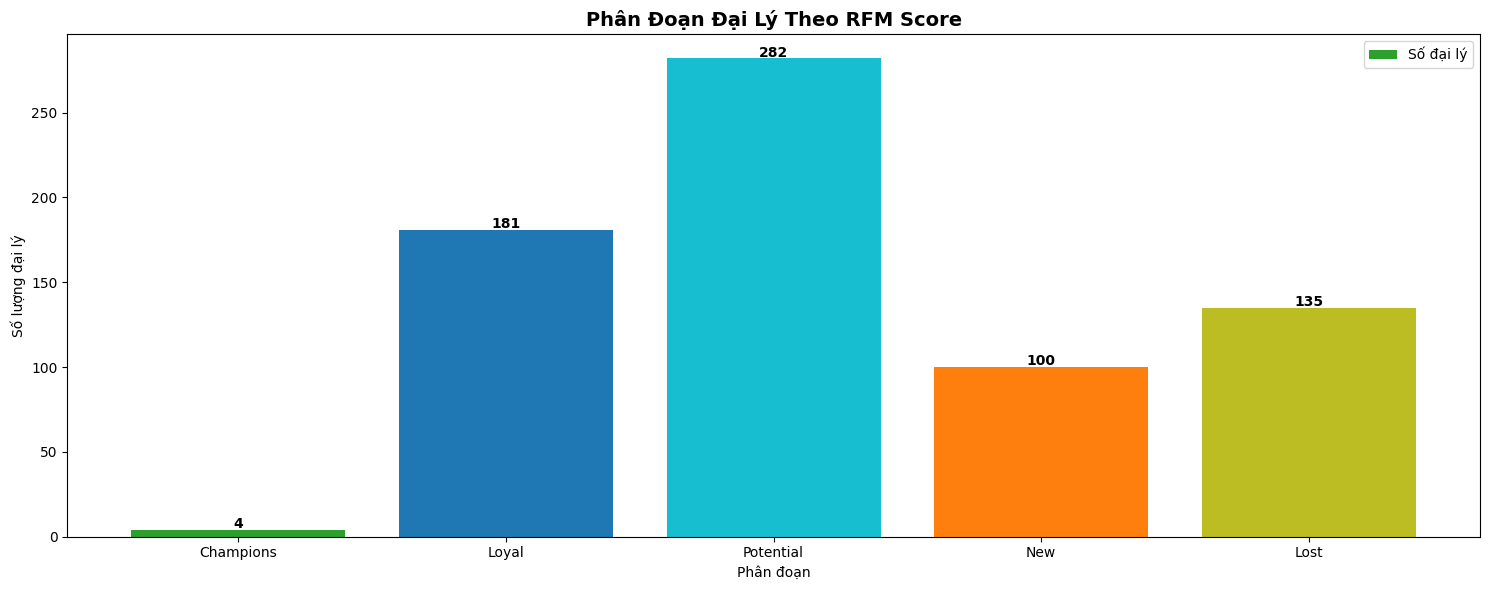

In [6]:
# Cell 6: Biểu đồ phân đoạn đại lý
seg_order = ['Champions','Loyal','Potential','New','At-Risk','Lost']
seg_plot = seg_counts.reindex([s for s in seg_order if s in seg_counts.index])

fig, ax = plt.subplots(figsize=(15, 6))
bar_colors = ['C2','C0','C9','C1','C8','C3']
ax.bar(seg_plot.index, seg_plot.values,
       color=bar_colors[:len(seg_plot)])
for i, (seg, val) in enumerate(seg_plot.items()):
    ax.text(i, val + 1, str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Phân Đoạn Đại Lý Theo RFM Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Phân đoạn')
ax.set_ylabel('Số lượng đại lý')
ax.legend(['Số đại lý'])
fig.tight_layout()
plt.show()

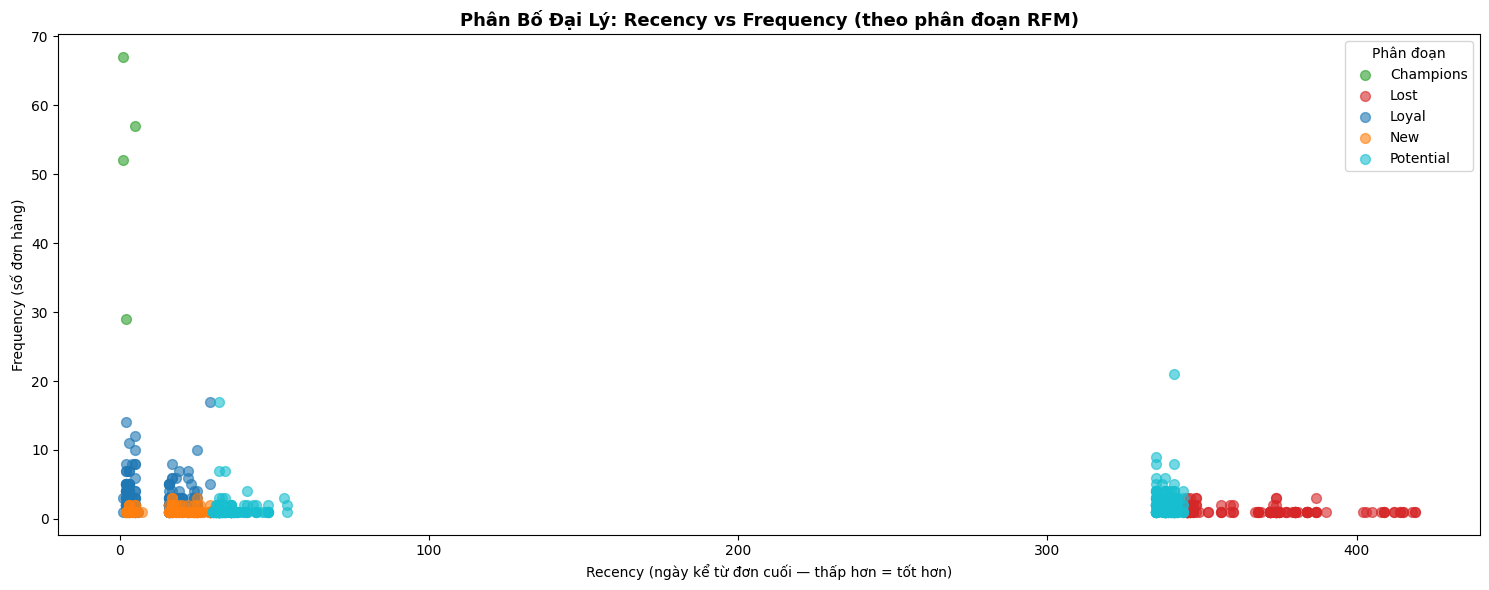

In [7]:
# Cell 7: RFM scatter — Recency vs Frequency (colored by segment)
seg_colors_map = {
    'Champions': 'C2', 'Loyal': 'C0', 'Potential': 'C9',
    'New': 'C1', 'At-Risk': 'C8', 'Lost': 'C3'
}
fig, ax = plt.subplots(figsize=(15, 6))
for seg, grp in rfm.groupby('segment'):
    color = seg_colors_map.get(seg, 'gray')
    ax.scatter(grp['recency'], grp['frequency'],
               alpha=0.6, label=seg, color=color, s=50)
ax.set_title('Phân Bố Đại Lý: Recency vs Frequency (theo phân đoạn RFM)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recency (ngày kể từ đơn cuối — thấp hơn = tốt hơn)')
ax.set_ylabel('Frequency (số đơn hàng)')
ax.legend(title='Phân đoạn')
fig.tight_layout()
plt.show()

In [8]:
# Cell 8: Model 2 — Logistic Regression → predict reorder_30d
# Label: đại lý đặt hàng trong Feb 2026 = 1, else = 0
# Features: RFM tính từ data Jan 2026 trở về trước

df_train_lr = df[df['year_month'].astype(str) <= '2026-01']
rfm_jan = df_train_lr.groupby('customer_code').agg(
    recency_jan=('order_date', lambda x: (pd.Timestamp('2026-02-01') - x.max()).days),
    frequency_jan=('so_number', 'nunique'),
    monetary_jan=('line_total', 'sum')
).reset_index()

# Label: đặt hàng Feb 2026?
feb_buyers = set(df[df['year_month'].astype(str) == '2026-02']['customer_code'].unique())
rfm_jan['reorder_feb'] = rfm_jan['customer_code'].isin(feb_buyers).astype(int)

print(f'Đại lý có data Jan: {len(rfm_jan)}')
print(f'Label reorder Feb 2026: {rfm_jan["reorder_feb"].value_counts().to_dict()}')

Đại lý có data Jan: 588
Label reorder Feb 2026: {0: 434, 1: 154}


In [9]:
# Cell 9: Train Logistic Regression
feat_cols = ['recency_jan', 'frequency_jan', 'monetary_jan']
X_lr = rfm_jan[feat_cols].fillna(0).values
y_lr = rfm_jan['reorder_feb'].values

scaler = StandardScaler()
X_lr_s = scaler.fit_transform(X_lr)

# In-sample training (all Jan data → predict Feb)
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
log_reg.fit(X_lr_s, y_lr)
y_pred_lr = log_reg.predict(X_lr_s)

print('Logistic Regression — In-sample performance (Jan→Feb transition):')
print(f'Accuracy:  {accuracy_score(y_lr, y_pred_lr):.3f}')
print(f'Precision: {precision_score(y_lr, y_pred_lr, zero_division=0):.3f}')
print(f'Recall:    {recall_score(y_lr, y_pred_lr, zero_division=0):.3f}')
print(classification_report(y_lr, y_pred_lr, zero_division=0))

Logistic Regression — In-sample performance (Jan→Feb transition):
Accuracy:  0.733
Precision: 0.495
Recall:    0.935
              precision    recall  f1-score   support

           0       0.97      0.66      0.79       434
           1       0.49      0.94      0.65       154

    accuracy                           0.73       588
   macro avg       0.73      0.80      0.72       588
weighted avg       0.84      0.73      0.75       588



In [10]:
# Cell 10: Predict Apr 2026 reorder probability
# Features = RFM from Feb 2026 data
df_feb = df[df['year_month'].astype(str) <= '2026-02']
rfm_feb = df_feb.groupby('customer_code').agg(
    recency_feb=('order_date', lambda x: (pd.Timestamp('2026-03-01') - x.max()).days),
    frequency_feb=('so_number', 'nunique'),
    monetary_feb=('line_total', 'sum')
).reset_index()

X_pred = rfm_feb[['recency_feb','frequency_feb','monetary_feb']].fillna(0).values
X_pred_s = scaler.transform(X_pred)
rfm_feb['reorder_prob_apr'] = log_reg.predict_proba(X_pred_s)[:, 1]

# Merge với RFM & segment info
dealer_risk = rfm_feb.merge(rfm[['customer_code','segment','customer_name']], on='customer_code', how='left')
dealer_risk['risk_level'] = pd.cut(dealer_risk['reorder_prob_apr'],
                                    bins=[0, 0.3, 0.6, 1.01],
                                    labels=['High Risk', 'Medium Risk', 'Low Risk'])
print('Risk level distribution:')
print(dealer_risk['risk_level'].value_counts())

Risk level distribution:
risk_level
Low Risk       406
High Risk      286
Medium Risk     10
Name: count, dtype: int64


In [11]:
# Cell 11: Model 3 — BG-NBD (lifetimes) với graceful fallback
try:
    from lifetimes import BetaGeoFitter, GammaGammaFitter
    from lifetimes.utils import summary_data_from_transaction_data
    
    bgf_data = summary_data_from_transaction_data(
        df, customer_id_col='customer_code',
        datetime_col='order_date',
        monetary_value_col='line_total',
        observation_period_end=pd.Timestamp('2026-02-28'),
        freq='M'
    )
    bgf = BetaGeoFitter(penalizer_coef=0.001)
    bgf.fit(bgf_data['frequency'], bgf_data['recency'], bgf_data['T'])
    bgf_data['pred_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
        90, bgf_data['frequency'], bgf_data['recency'], bgf_data['T']
    )
    
    # Gamma-Gamma CLV
    gg_data = bgf_data[bgf_data['monetary_value'] > 0]
    ggf = GammaGammaFitter(penalizer_coef=0.001)
    ggf.fit(gg_data['frequency'], gg_data['monetary_value'])
    gg_data = gg_data.copy()
    gg_data['expected_avg_revenue'] = ggf.conditional_expected_average_profit(
        gg_data['frequency'], gg_data['monetary_value']
    )
    bgf_data = bgf_data.join(gg_data[['expected_avg_revenue']], how='left')
    bgf_data['CLV_90d'] = bgf_data['pred_purchases_90d'] * bgf_data['expected_avg_revenue'].fillna(0)
    
    print('BG-NBD + Gamma-Gamma CLV computed successfully!')
    print(f'Avg predicted purchases next 90d: {bgf_data["pred_purchases_90d"].mean():.2f}')
    print(bgf_data[['frequency','recency','T','pred_purchases_90d','CLV_90d']].head().round(2))
    BG_NBD_OK = True
except ImportError:
    print('[INFO] lifetimes không khả dụng — bỏ qua BG-NBD. Dùng RFM + LogReg.')
    BG_NBD_OK = False
    bgf_data = None
except Exception as e:
    print(f'[WARNING] BG-NBD lỗi: {e} — fallback to RFM scoring.')
    BG_NBD_OK = False
    bgf_data = None

[WARNING] BG-NBD lỗi: Unit M is not supported. Only unambiguous timedelta values durations are supported. Allowed units are 'W', 'D', 'h', 'm', 's', 'ms', 'us', 'ns' — fallback to RFM scoring.


In [12]:
# Cell 12: Dealer risk table — top 20 cần ưu tiên
priority_cols = ['customer_code','customer_name','reorder_prob_apr','risk_level','segment']
high_risk = dealer_risk[dealer_risk['risk_level'] == 'High Risk'].sort_values('reorder_prob_apr').head(20)

print('Top 20 đại lý HIGH RISK (cần chăm sóc khẩn cấp):')
for _, row in high_risk.head(10).iterrows():
    name = str(row.get('customer_name', row['customer_code']))[:40]
    print(f"  {row['customer_code']} | {name:40s} | prob={row['reorder_prob_apr']:.2f} | seg={row['segment']}")

Top 20 đại lý HIGH RISK (cần chăm sóc khẩn cấp):
  KH-00003 | CÔNG TY CỔ PHẦN THƯƠNG MẠI NAM TIẾN      | prob=0.03 | seg=Lost
  KH-00002 | CÔNG TY TNHH THƯƠNG MẠI VIỆT ANH         | prob=0.03 | seg=Lost
  KH-00005 | CÔNG TY TNHH ĐẠI LỢI                     | prob=0.03 | seg=Lost
  KH-00013 | DOANH NGHIỆP TW THANH BÌNH               | prob=0.03 | seg=Lost
  KH-00026 | CÔNG TY CỔ PHẦN LÊ ANH                   | prob=0.03 | seg=Lost
  KH-00017 | CỬA HÀNG XE ĐẠP THUỶ TIÊN                | prob=0.03 | seg=Lost
  KH-00032 | HỘ KINH DOANH CHI THÀNH                  | prob=0.03 | seg=Lost
  KH-00025 | DOANH NGHIỆP TW SƠN HÀ                   | prob=0.03 | seg=Lost
  KH-00029 | CÔNG TY TNHH THƯƠNG MẠI THANH BÌNH       | prob=0.03 | seg=Lost
  KH-00031 | CÔNG TY CỔ PHẦN THƯƠNG MẠI ĐẠI DƯƠNG     | prob=0.03 | seg=Lost


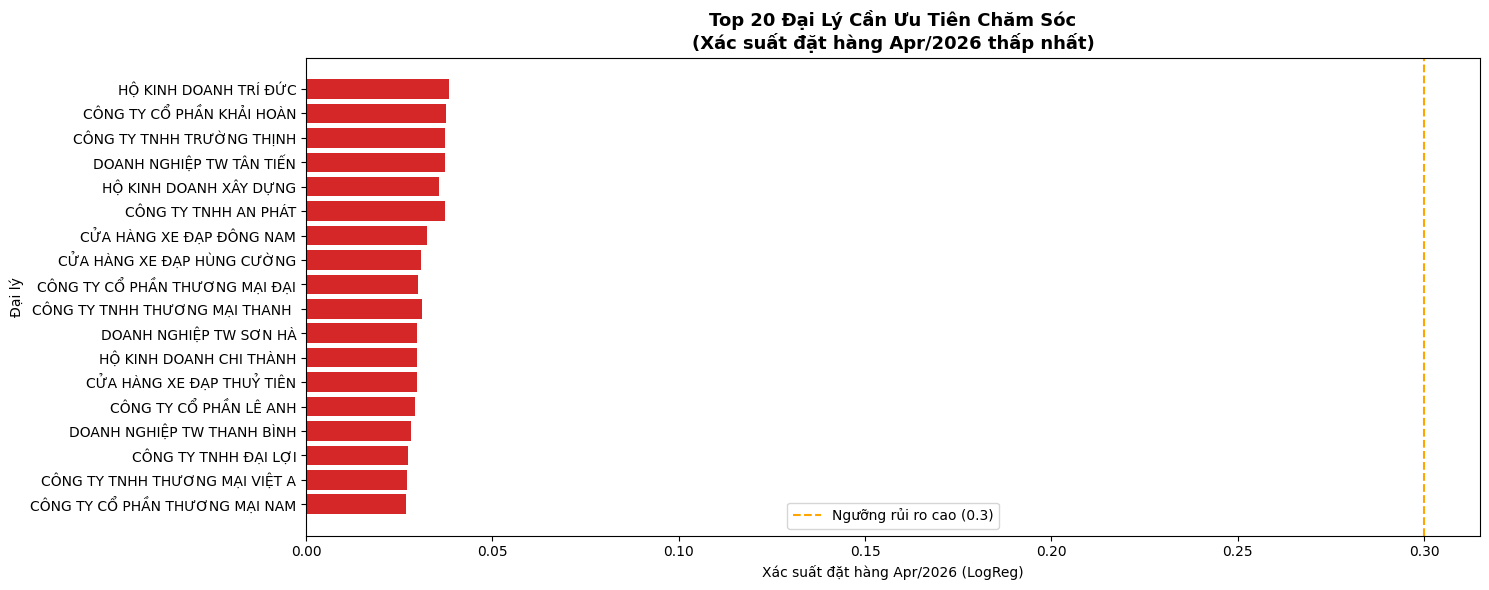

In [13]:
# Cell 13: Biểu đồ top 20 priority dealers (xác suất đặt hàng thấp nhất)
plot_data = high_risk.head(20).copy()
plot_data['short_name'] = plot_data['customer_name'].astype(str).str[:30]

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(plot_data['short_name'], plot_data['reorder_prob_apr'], color='C3')
ax.axvline(0.3, color='orange', linestyle='--', linewidth=1.5, label='Ngưỡng rủi ro cao (0.3)')
ax.set_title('Top 20 Đại Lý Cần Ưu Tiên Chăm Sóc\n(Xác suất đặt hàng Apr/2026 thấp nhất)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Xác suất đặt hàng Apr/2026 (LogReg)')
ax.set_ylabel('Đại lý')
ax.legend()
fig.tight_layout()
plt.show()

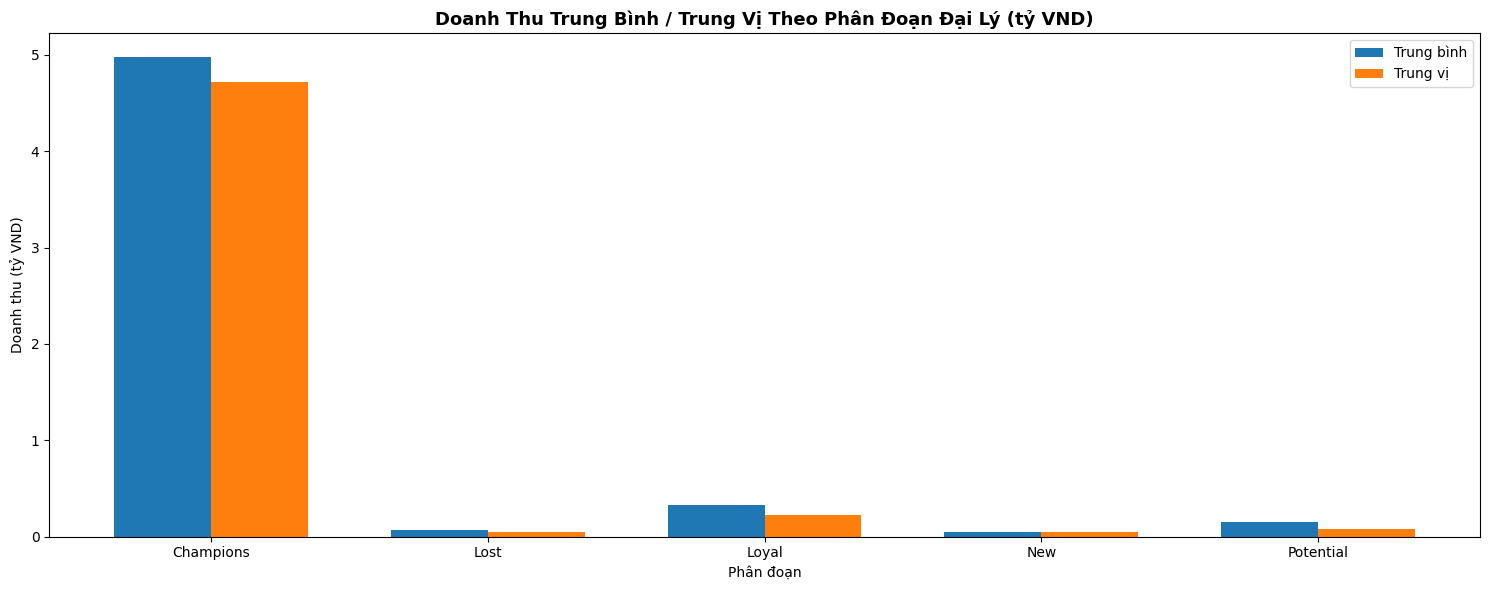

In [14]:
# Cell 14: Monetary distribution by segment (box-style via bar)
seg_monetary = dealer_risk.groupby('segment')['monetary_feb'].agg(['mean','median']).reset_index()

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(seg_monetary))
w = 0.35
ax.bar(x - w/2, seg_monetary['mean'] / 1e9, width=w, label='Trung bình', color='C0')
ax.bar(x + w/2, seg_monetary['median'] / 1e9, width=w, label='Trung vị', color='C1')
ax.set_xticks(x)
ax.set_xticklabels(seg_monetary['segment'])
ax.set_title('Doanh Thu Trung Bình / Trung Vị Theo Phân Đoạn Đại Lý (tỷ VND)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Phân đoạn')
ax.set_ylabel('Doanh thu (tỷ VND)')
ax.legend()
fig.tight_layout()
plt.show()

[INFO] BG-NBD không khả dụng — bỏ qua biểu đồ CLV.
Dùng RFM total score làm proxy CLV:


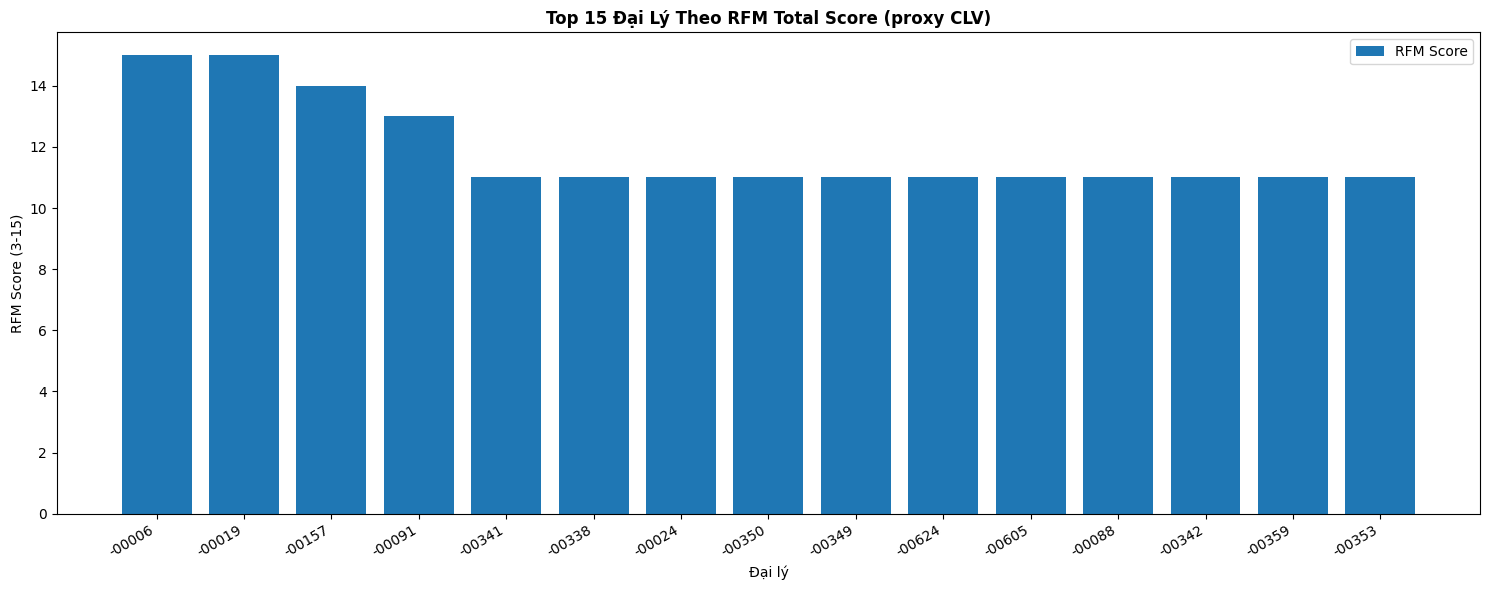

In [15]:
# Cell 15: CLV từ BG-NBD (nếu có)
if BG_NBD_OK and bgf_data is not None:
    top_clv = bgf_data.sort_values('CLV_90d', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.bar(range(len(top_clv)), top_clv['CLV_90d'] / 1e6, color='C0')
    ax.set_xticks(range(len(top_clv)))
    ax.set_xticklabels(top_clv.index.str[-6:], rotation=30, ha='right')
    ax.set_title('Top 15 Đại Lý Theo Customer Lifetime Value 90 ngày (BG-NBD + Gamma-Gamma)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Đại lý')
    ax.set_ylabel('CLV 90 ngày (triệu VND)')
    ax.legend(['CLV ước tính'])
    fig.tight_layout()
    plt.show()
else:
    print('[INFO] BG-NBD không khả dụng — bỏ qua biểu đồ CLV.')
    print('Dùng RFM total score làm proxy CLV:')
    rfm_proxy = rfm.sort_values('RFM_total', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.bar(range(len(rfm_proxy)), rfm_proxy['RFM_total'], color='C0')
    ax.set_xticks(range(len(rfm_proxy)))
    ax.set_xticklabels(rfm_proxy['customer_code'].str[-6:], rotation=30, ha='right')
    ax.set_title('Top 15 Đại Lý Theo RFM Total Score (proxy CLV)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Đại lý')
    ax.set_ylabel('RFM Score (3-15)')
    ax.legend(['RFM Score'])
    fig.tight_layout()
    plt.show()

## Kết Luận Q3: Phân Tích Hoạt Động Đại Lý

**RFM Segmentation:**
- Champions: đại lý mua thường xuyên, doanh thu cao, gần đây — ưu tiên giữ chân
- At-Risk: đại lý từng mua nhiều nhưng đang giảm tần suất — cần tái kích hoạt
- Lost: không mua hàng lâu — xem xét chiến dịch win-back

**Logistic Regression (Churn Prediction):**
- Recency là yếu tố quan trọng nhất dự đoán khả năng đặt hàng lại
- Các đại lý High Risk cần được sales team liên hệ trong tháng 3/2026

**Khuyến nghị CEO:**
- Lập danh sách 20 đại lý ưu tiên chăm sóc (prob < 0.3)
- Chương trình loyalty cho nhóm Champions để duy trì tần suất mua
- Chương trình tái kích hoạt (ưu đãi) cho nhóm At-Risk
- Theo dõi CLV thực tế Q2 để validate dự báo BG-NBD